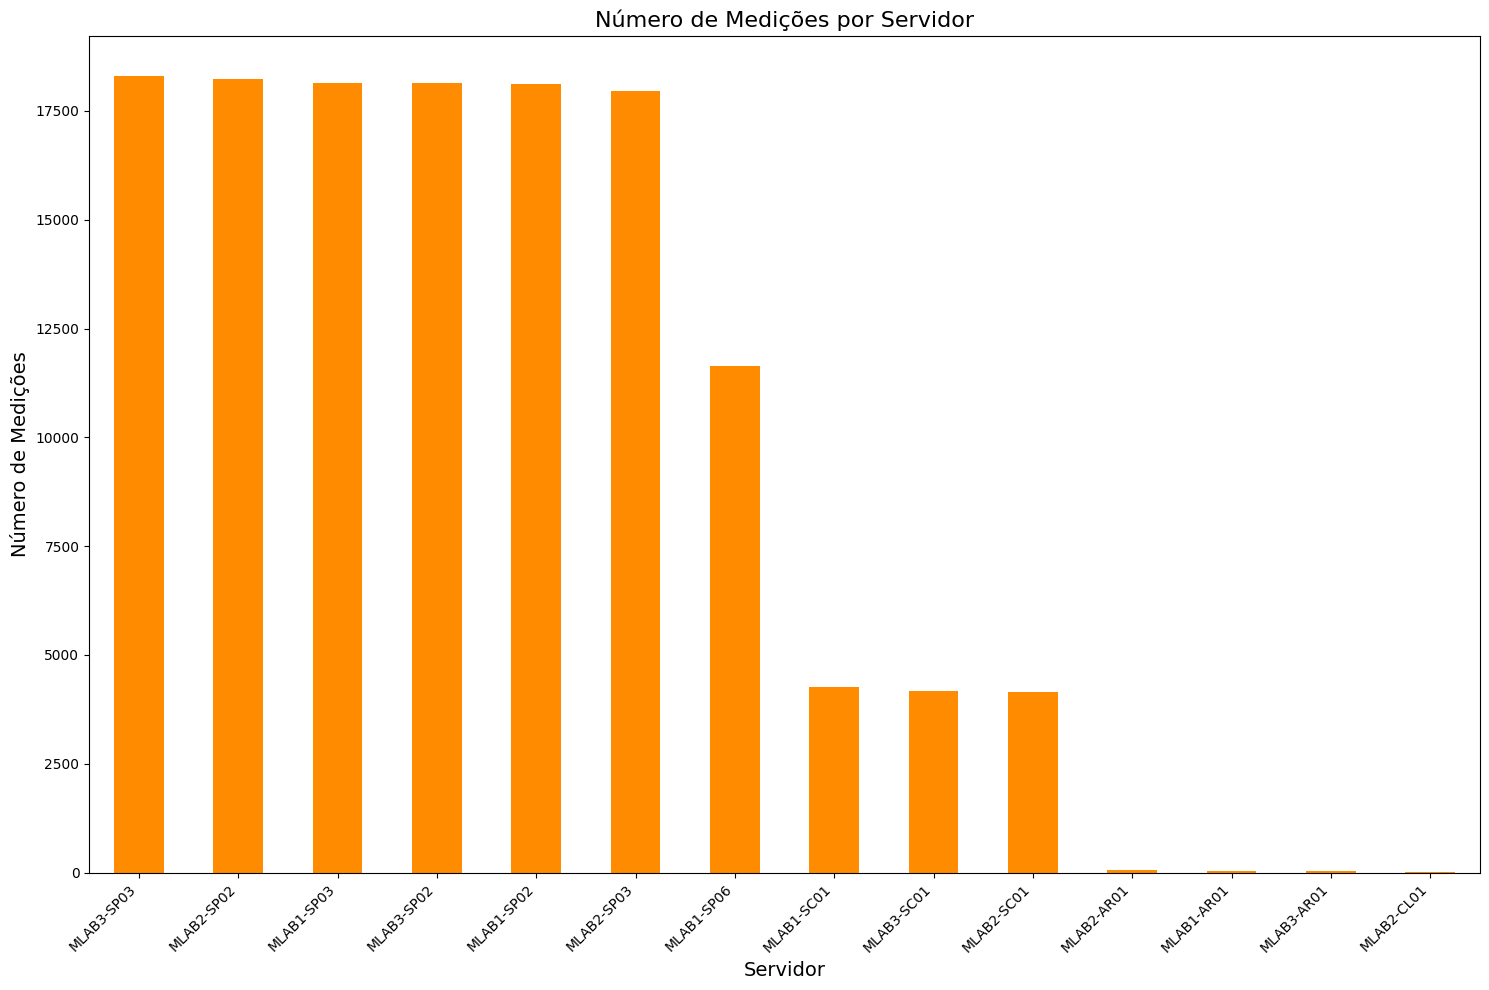

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Carregamento do dataset
file = 'NDT_transformed.csv'
file_path = os.path.join("NDT dataset", file)
df = pd.read_csv(file_path)
clean = True

# Conversão de timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['data'] = df['timestamp'].dt.date

# pegar os servidores que começam com mlab
df = df[df['server_name'].fillna('').str.startswith('MLAB')]

# Criar coluna de par cliente-servidor
df['client_server_pair'] = df['client_name'] + " -> " + df['server_name']

# Ordenar por tempo e par
df = df.sort_values(by=['client_server_pair', 'timestamp']).reset_index(drop=True)

# Gráfico de Servidores
plt.figure(figsize=(15, 10))
medicoes_por_servidor = df['server_name'].value_counts()
medicoes_por_servidor.plot(kind='bar', color='darkorange')
plt.title('Número de Medições por Servidor', fontsize=16)
plt.xlabel('Servidor', fontsize=14)
plt.ylabel('Número de Medições', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [2]:
from scipy import stats
import pandas as pd

# Métricas de interesse
metricas = ['rtt_download', 'throughput_download', 'rtt_upload', 'throughput_upload', 'packet_loss']

# 1. Extração do site do server_name
df['site'] = df['server_name'].str.extract(r'-(.*?)(?:\.|$)')

# 2. Lógica de Teste de Homogeneidade
resultados_detalhados = []
grouped = df.groupby(['client_name', 'site'])

for (cliente, site), group_data in grouped:
    servidores = group_data['server_name'].unique()
    
    if len(servidores) > 1:
        site_homogeneo = True
        motivo_falha = "Nenhum"
        
        for m in metricas:
            for s_alvo in servidores:
                data_alvo = group_data[group_data['server_name'] == s_alvo][m].dropna()
                data_resto = group_data[group_data['server_name'] != s_alvo][m].dropna()
                
                if len(data_alvo) >= 10 and len(data_resto) >= 10:
                    ks_stat, ks_p = stats.ks_2samp(data_alvo, data_resto)
                    mw_stat, mw_p = stats.mannwhitneyu(data_alvo, data_resto)
                    
                    if ks_p <= 0.05 or mw_p <= 0.05:
                        site_homogeneo = False
                        motivo_falha = f"Métrica {m} divergente (KS p-val: {ks_p:.4f})"
                        break
            if not site_homogeneo: break
        
        resultados_detalhados.append({
            'client_site': f"{cliente} -> {site}",
            'homogeneo': site_homogeneo,
            'motivo': motivo_falha
        })
    else:
        resultados_detalhados.append({
            'client_site': f"{cliente} -> {site}", 
            'homogeneo': True, 
            'motivo': "Servidor único"
        })

# 3. Exibir os resultados
df_decisao = pd.DataFrame(resultados_detalhados)

print("--- Resumo dos Testes de Homogeneidade ---")
print(f"Total de pares (Cliente->Site) avaliados: {len(df_decisao)}")
print(f"Pares aprovados (Homogêneos): {len(df_decisao[df_decisao['homogeneo'] == True])}")
print(f"Pares reprovados (Heterogêneos): {len(df_decisao[df_decisao['homogeneo'] == False])}")

print("\n--- Detalhes dos Pares Reprovados ---")
print(df_decisao[df_decisao['homogeneo'] == False][['client_site', 'motivo']])

# salvar relatorio em csv
df_decisao.to_csv('NDT dataset/mlab_homogeneidade.csv', index=False)

--- Resumo dos Testes de Homogeneidade ---
Total de pares (Cliente->Site) avaliados: 84
Pares aprovados (Homogêneos): 52
Pares reprovados (Heterogêneos): 32

--- Detalhes dos Pares Reprovados ---
              client_site                                             motivo
1            Curi -> SC01  Métrica throughput_upload divergente (KS p-val...
8           Edson -> SP03  Métrica throughput_download divergente (KS p-v...
12        Edworld -> SP02  Métrica rtt_download divergente (KS p-val: 0.1...
13        Edworld -> SP03  Métrica rtt_download divergente (KS p-val: 0.0...
21  Gigalink-ARBU -> SC01  Métrica rtt_download divergente (KS p-val: 0.0...
22  Gigalink-ARBU -> SP02  Métrica throughput_download divergente (KS p-v...
23  Gigalink-ARBU -> SP03  Métrica throughput_download divergente (KS p-v...
26   Gigalink-BSC -> SC01  Métrica rtt_download divergente (KS p-val: 0.0...
27   Gigalink-BSC -> SP02  Métrica throughput_download divergente (KS p-v...
28   Gigalink-BSC -> SP03  Métrica